# ADCNN evaluation — catalog-based

Pure analysis of the **pre-generated detection catalogs** (no inference here). The catalogs
are produced by `python -m ADCNN.pipelines.make_eval_catalogs` (deployed v7 + neg5 RF,
`gate_pmax=0.10`) and live in `Evaluation/catalogs/`. This notebook loads each measured
catalog + the truth catalog, matches trails (any-pixel-overlap, fixed `tol_px`, all-trails
denominator), and reports object-level detection metrics, completeness, and parameter recovery.

Operating point (RF score cut) and match tolerance are fixed in advance — no tuning on the test set.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
REPO = Path('.').resolve(); sys.path.insert(0, str(REPO))
import ADCNN.evaluation.detection as evals
from ADCNN.evaluation.catalog_match import evaluate_catalog, match_pairs
from ADCNN.inference.rf_postproc import DEFAULT_THR

CATALOGS = REPO / 'Evaluation/catalogs'
DATA = REPO / 'DATA_DIFFIM'
TOL_PX = 20.0
print(f'RF operating point = {DEFAULT_THR} | match tol = {TOL_PX} px | catalogs = {CATALOGS}')

RF operating point = 0.5 | match tol = 20.0 px | catalogs = /sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN/Evaluation/catalogs


In [2]:
def evaluate_set(name):
    """Load measured catalog + truth for `name`, match, return (counts, truth_flagged, pairs)."""
    cat = pd.read_csv(CATALOGS / f'{name}_detections.csv')
    truth = pd.read_csv(DATA / name / 'test.csv')
    counts, truth_out = evaluate_catalog(cat, truth, tol_px=TOL_PX)
    truth_out['stack_detection'] = truth_out['stack_detection'].astype(bool)
    pairs = match_pairs(cat, truth, tol_px=TOL_PX)
    return counts, truth_out, pairs

def show_confusion(counts, title):
    evals.print_confusion_matrix({'TN': pd.NA, 'FP': counts['FP'], 'FN': counts['FN'], 'TP': counts['TP']}, title=title)
    print(f"recall={counts['recall']:.3f}  FP/panel={counts['fp_per_panel']:.1f}  "
          f"({counts['TP']} TP / {counts['TP']+counts['FN']} truth trails; all-trails denominator)")

## 5σ + NN (hero)

In [3]:
counts5, truth5, pairs5 = evaluate_set('test_5sigma')
show_confusion(counts5, '5sigma + NN — object-level (catalog trail-overlap)')
comb = truth5['nn_detected'].astype(bool) | truth5['stack_detection']
print(f"NN={int(truth5.nn_detected.sum())}  stack={int(truth5.stack_detection.sum())}  "
      f"combined(NN∪stack)={int(comb.sum())} / {len(truth5)} truth trails")

5sigma + NN — object-level (catalog trail-overlap)
F1 Score: 0.2736, F2 Score: 0.4367
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                3575
Actual Positive                 275                 725

recall=0.725  FP/panel=71.5  (725 TP / 1000 truth trails; all-trails denominator)
NN=725  stack=475  combined(NN∪stack)=739 / 1000 truth trails


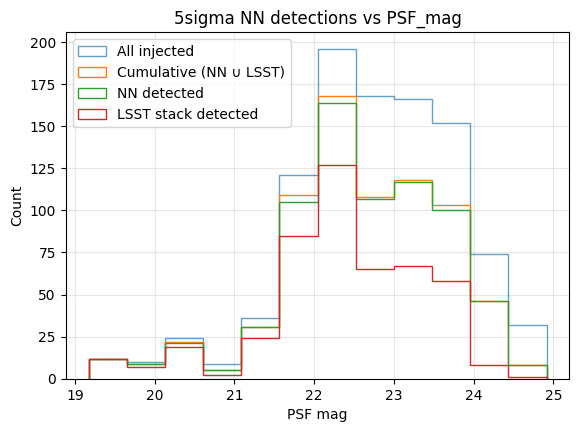

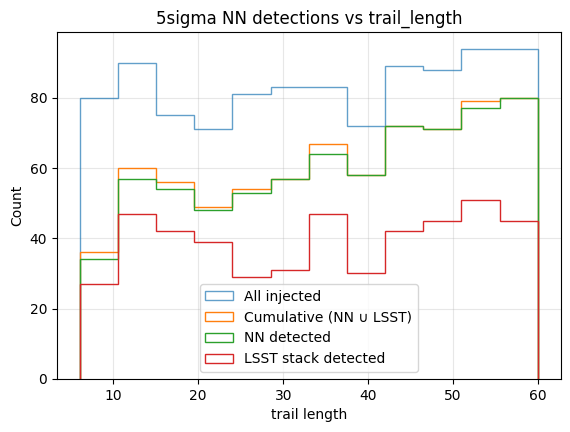

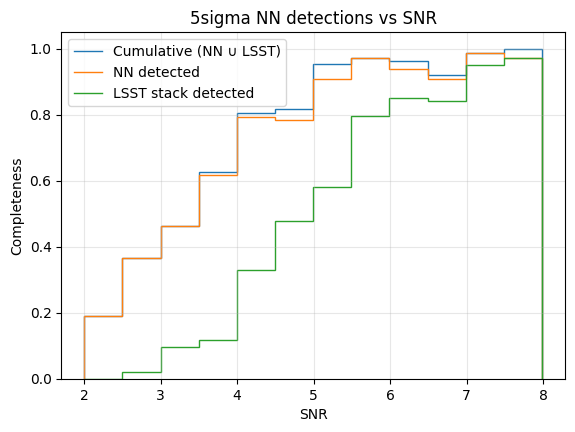

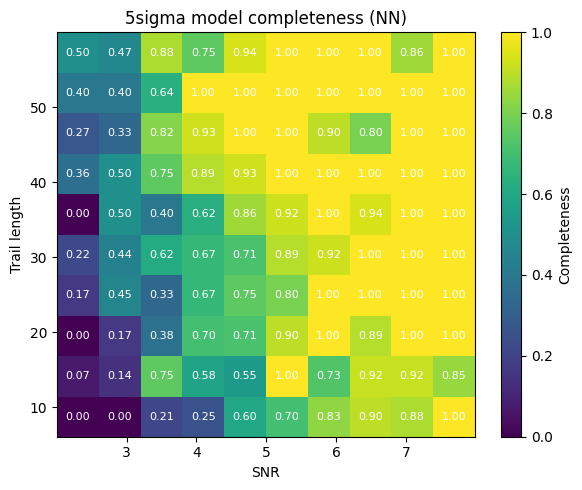

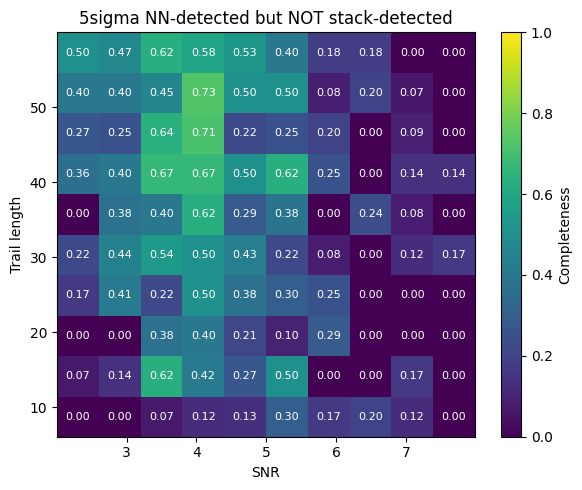

In [4]:
for field, kw in [('PSF_mag', {}), ('trail_length', {}), ('SNR', dict(xlim=[0,10], density=True))]:
    evals.plot_detect_hist(truth5, field, bins=12, title=f'5sigma NN detections vs {field}', **kw); plt.show()
evals.plot_completeness_2d(truth5, snr_bins=10, trail_bins=10, title='5sigma model completeness (NN)'); plt.show()
evals.plot_completeness_2d(truth5, snr_bins=10, trail_bins=10,
    detected=(~truth5['stack_detection'].values & truth5['nn_detected'].values.astype(bool)),
    title='5sigma NN-detected but NOT stack-detected'); plt.show()

### Parameter recovery (measured vs true geometry, matched trails)

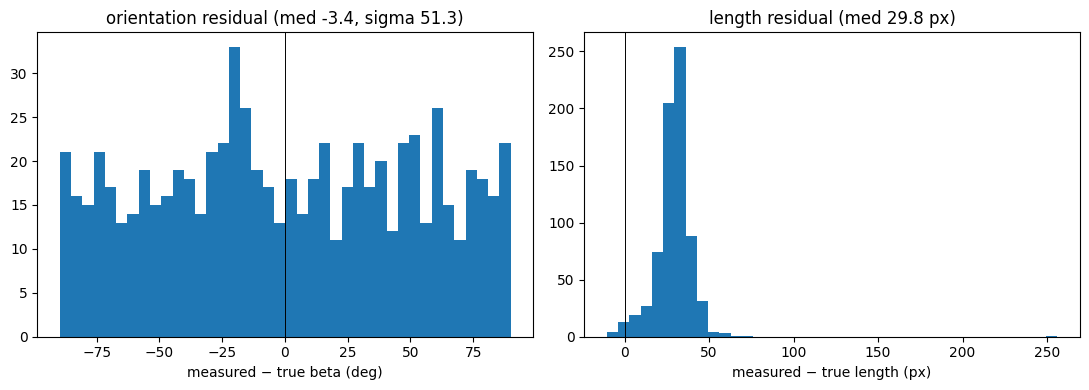

In [5]:
dbeta = ((pairs5.meas_beta - pairs5.beta + 90) % 180) - 90  # signed mod-180 orientation residual
dlen = pairs5.meas_length - pairs5.trail_length
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(dbeta, bins=40); ax[0].axvline(0, c='k', lw=0.7)
ax[0].set_xlabel('measured − true beta (deg)'); ax[0].set_title(f'orientation residual (med {dbeta.median():.1f}, sigma {dbeta.std():.1f})')
ax[1].hist(dlen, bins=40); ax[1].axvline(0, c='k', lw=0.7)
ax[1].set_xlabel('measured − true length (px)'); ax[1].set_title(f'length residual (med {dlen.median():.1f} px)')
plt.tight_layout(); plt.show()

## 4σ and 3σ

test_4sigma + NN — object-level
F1 Score: 0.3247, F2 Score: 0.4906
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                2838
Actual Positive                 256                 744

recall=0.744  FP/panel=56.8  (744 TP / 1000 truth trails; all-trails denominator)


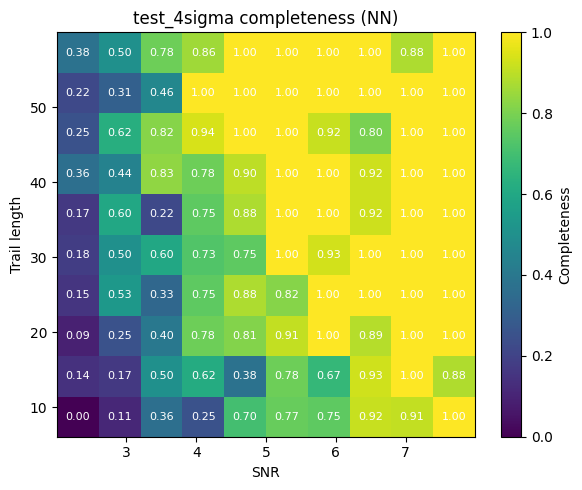

test_3sigma + NN — object-level
F1 Score: 0.4710, F2 Score: 0.6209
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                1558
Actual Positive                 212                 788

recall=0.788  FP/panel=31.2  (788 TP / 1000 truth trails; all-trails denominator)


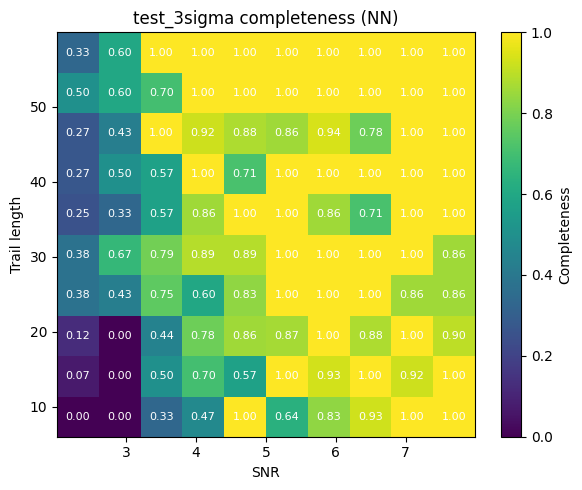

        set  TP   FP  FN  recall  fp_per_panel
test_4sigma 744 2838 256   0.744          56.8
test_3sigma 788 1558 212   0.788          31.2


In [6]:
rows = []
for name in ['test_4sigma', 'test_3sigma']:
    c, t, _ = evaluate_set(name)
    show_confusion(c, f'{name} + NN — object-level')
    evals.plot_completeness_2d(t, snr_bins=10, trail_bins=10, title=f'{name} completeness (NN)'); plt.show()
    rows.append(dict(set=name, TP=c['TP'], FP=c['FP'], FN=c['FN'], recall=round(c['recall'],3), fp_per_panel=round(c['fp_per_panel'],1)))
summary = pd.DataFrame(rows); print(summary.to_string(index=False))